In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm
import seaborn as sns
sns.set_style('darkgrid')

def bs_call(S0, K, sigma, t=1, r=0):
    """
    Description:
    
    Computes the Black-Scholes value of a European call option.
    
    Parameters:
        S0: Current asset price
        K: Strike price
        sigma: Yearly standard deviation of log-returns (volatility)
        t: Time to expiration (in years)
        r: Risk-free interest rate
    
    Returns:
        Call option price
    """
    d1 = (np.log(S0/K) + (r+.5*sigma**2)*t)/(sigma*np.sqrt(t))
    #d2 = (np.log(S0/K) + (r-.5*sigma**2)*t)/(sigma*np.sqrt(t))
    d2 = d1 - sigma*np.sqrt(t)
    return S0*norm.cdf(d1)-K*np.exp(-r*t)*norm.cdf(d2)


def bs_put(S0, K, sigma, t=1, r=0):
    """
    Description:
    
    Computes the Black-Scholes value of a European put option.
    
    Parameters:
        S0: Current asset price
        K: Strike price
        sigma: Yearly standard deviation of log-returns (volatility)
        t: Time to expiration (in years)
        r: Risk-free interest rate
    
    Returns:
        Put option price
    """
    
    d1 = (np.log(S0/K) + (r+.5*sigma**2)*t)/(sigma*np.sqrt(t))
    #d2 = (np.log(S0/K) + (r-.5*sigma**2)*t)/(sigma*np.sqrt(t))
    d2 = d1 - sigma*np.sqrt(t)
    return -S0*norm.cdf(-d1)+K*np.exp(-r*t)*norm.cdf(-d2)




## Option Price vs Time to Expiry

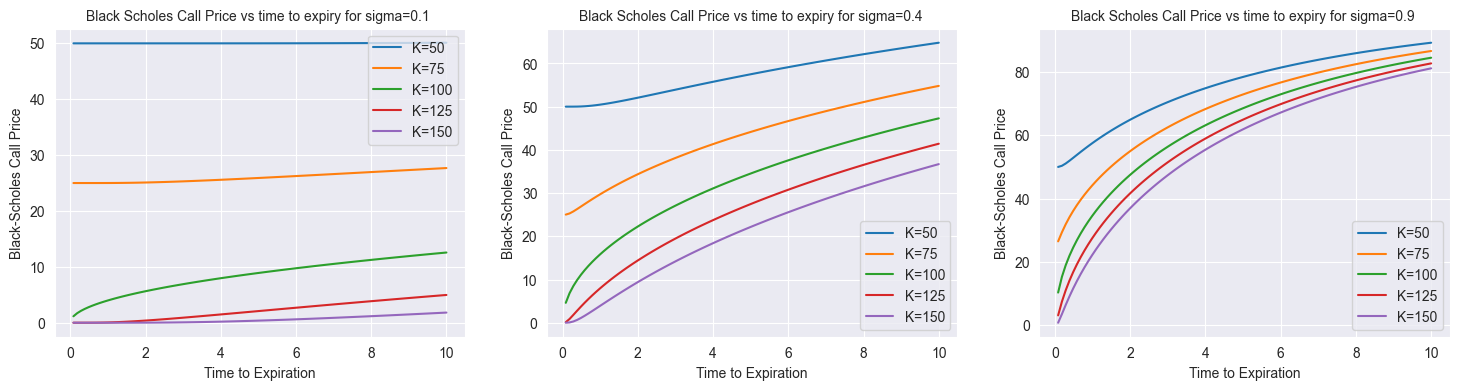

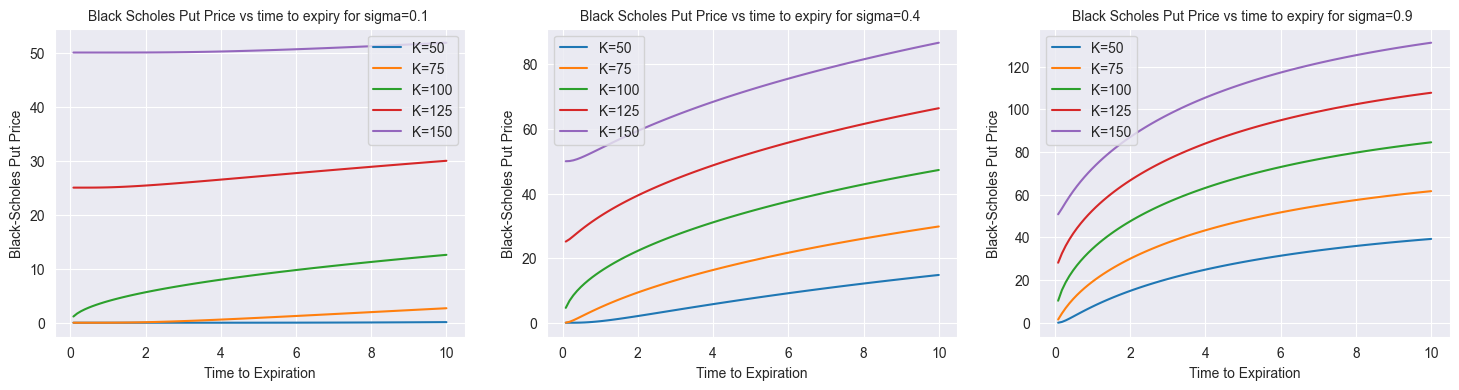

In [3]:
S0 = 100
K = [50,75,100,125,150]
sigma_list = [0.1, 0.4, 0.9]
times = np.linspace(1/12, 10, 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for i in range(len(sigma_list)):
    for strike_price in K:
        axes[i].plot(times, [bs_call(S0,strike_price,sigma_list[i], t = times[j]) for j in range(len(times))], label=f'K={strike_price}')
    axes[i].set_xlabel('Time to Expiration')
    axes[i].set_ylabel('Black-Scholes Call Price')
    axes[i].set_title(f'Black Scholes Call Price vs time to expiry for sigma={sigma_list[i]} ', size = 10)
    axes[i].legend()

plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for i in range(len(sigma_list)):
    for strike_price in K:
        axes[i].plot(times, [bs_put(S0,strike_price,sigma_list[i], t = times[j]) for j in range(len(times))], label=f'K={strike_price}')
    axes[i].set_xlabel('Time to Expiration')
    axes[i].set_ylabel('Black-Scholes Put Price')
    axes[i].set_title(f'Black Scholes Put Price vs time to expiry for sigma={sigma_list[i]} ', size = 10)
    axes[i].legend()

plt.show()

## Observations

* For low volatility, in the money options are priced near to the differences in the spot and strike price. This makes sense since due to low volatlity we expect stock price at expiry to remain similar to current spot price. Out of the money options are priced around 0 near to expiry and become slightly valuable as time to expiry (tte) increases, reflecting the small (due to low volatility) chance that the option might become in the money at expiry.
* As volatility increases, both in the money and out of the money options gain value as tte increases since more scenarios arise in which the option can become in the money at expiry.
* Call option prices always remain below the spot price since otherwise it is beneficial to buy the stock itself instead of the option. 
* Put option prices always remain below the strike price since the payoff is never higher than the strike price. 

## Delta vs time to expiry

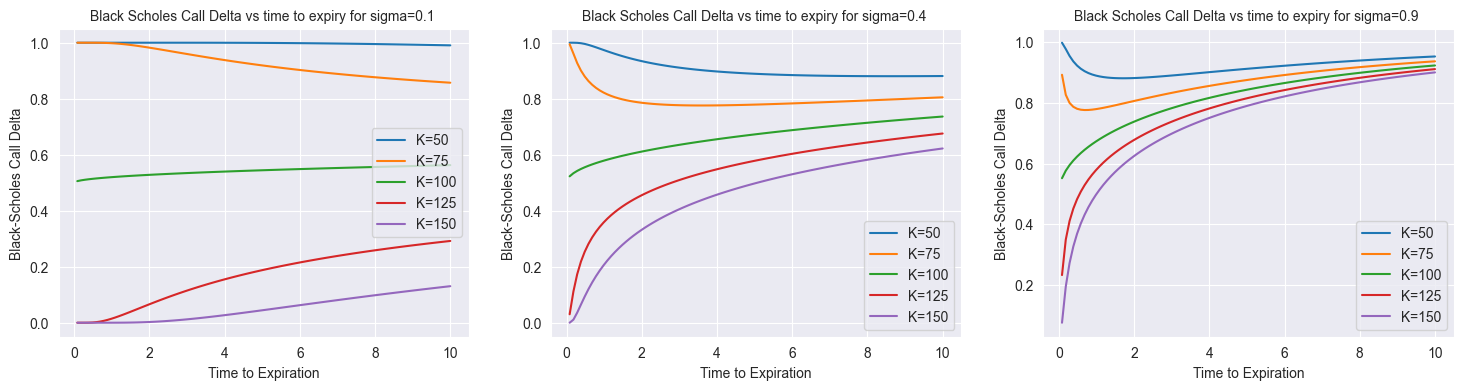

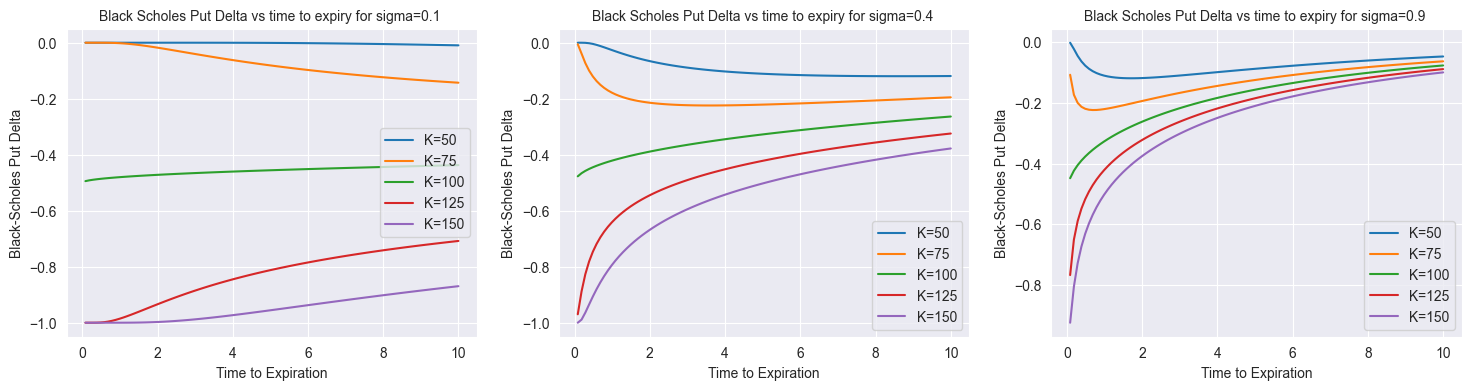

In [14]:
S0 = 100
K = [50,75,100,125,150]
sigma_list = [0.1, 0.4, 0.9]
times = np.linspace(1/12, 10, 100)
epsilon=0.005

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for i in range(len(sigma_list)):
    for strike_price in K:
        axes[i].plot(times, [(bs_call(S0*(1+epsilon),strike_price,sigma_list[i], t = times[j]) - bs_call(S0*(1-epsilon),strike_price,sigma_list[i], t = times[j]))/(2*S0*epsilon) for j in range(len(times))], label=f'K={strike_price}')
    axes[i].set_xlabel('Time to Expiration')
    axes[i].set_ylabel('Black-Scholes Call Delta')
    axes[i].set_title(f'Black Scholes Call Delta vs time to expiry for sigma={sigma_list[i]} ', size = 10)
    axes[i].legend()

plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for i in range(len(sigma_list)):
    for strike_price in K:
        axes[i].plot(times, [(bs_put(S0*(1+epsilon),strike_price,sigma_list[i], t = times[j]) - bs_put(S0*(1-epsilon),strike_price,sigma_list[i], t = times[j]))/(2*S0*epsilon) for j in range(len(times))], label=f'K={strike_price}')
    axes[i].set_xlabel('Time to Expiration')
    axes[i].set_ylabel('Black-Scholes Put Delta')
    axes[i].set_title(f'Black Scholes Put Delta vs time to expiry for sigma={sigma_list[i]} ', size = 10)
    axes[i].legend()

plt.show()


## Observations
* The value of a call option always increases with the spot price for a fixed strike price since the distribution of prices at expiry also increases with the spot price, pushing up the value of the option at expiry. The opposite happens for a put options so delta is always positive for call options and negative for put options.
* For call options in the regime where the major contribution to the option price comes form large upsides, the delta increases with tte since these upsides are also magnified more as tte increases. This can be seen in the high volatility scenario.
*  For call options in the regime where the non-negligible contributions to the option price can come from the price at expiry being lower than the spot price, delta can decrease with increase in tte which allows for more trajectories with smaller payoff. For instance, in the first graph with K=75, for small tte, the stock price is expected to remain near S0 so the option price essentially S0-K, which has a delta of 1. As tte increases, there are scenarios where the stock prices can go lower at expiry than at the start, and the end point of such trajectories go up by a factor of less than 1 times the increase in spot price. These contribute to a delta smaller than 1.

## Delta vs Spot Prices

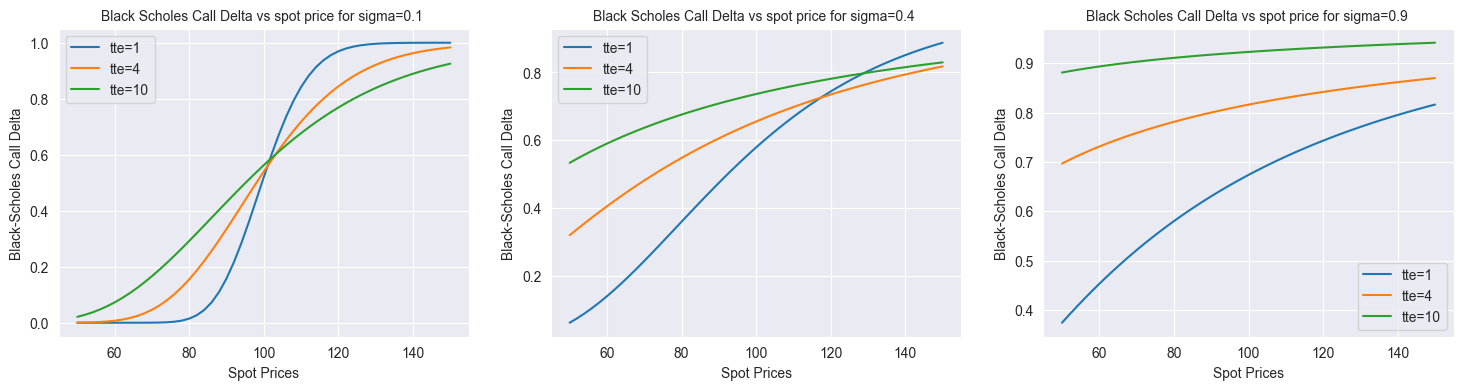

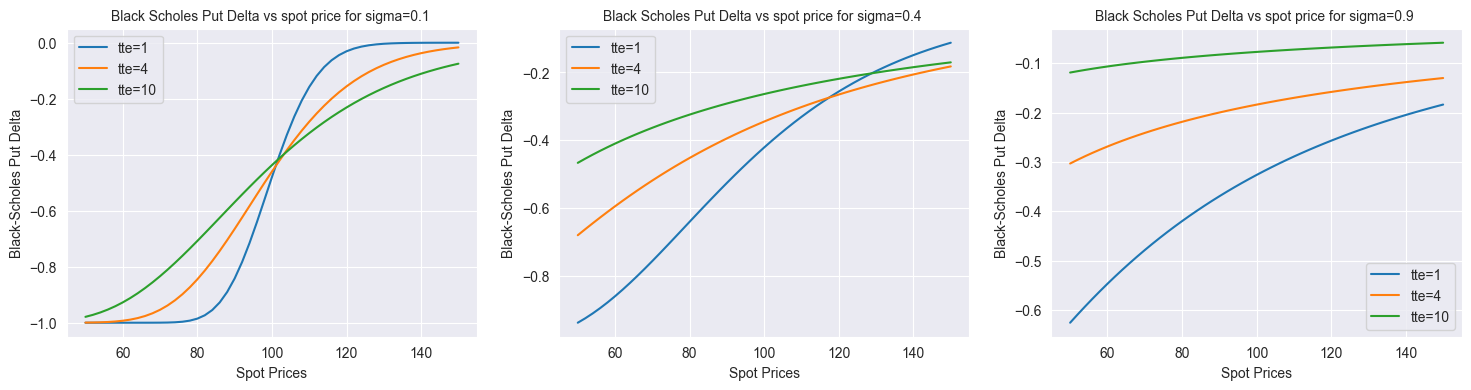

In [17]:
spot_prices = [i for i in range(50,151, 2)]
K = 100
sigma_list = [0.1, 0.4, 0.9]
times = [1,4,10]
epsilon=0.005

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for j in range(len(sigma_list)):
    for time in times:
        axes[j].plot(spot_prices, [(bs_call(S*(1+epsilon),100,sigma_list[j], t = time) - bs_call(S*(1-epsilon),100,sigma_list[j], t = time))/(2*S*epsilon) for S in spot_prices], label=f'tte={time}')
    axes[j].set_xlabel('Spot Prices')
    axes[j].set_ylabel('Black-Scholes Call Delta')
    axes[j].set_title(f'Black Scholes Call Delta vs spot price for sigma={sigma_list[j]} ', size = 10)
    axes[j].legend()

plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for j in range(len(sigma_list)):
    for time in times:
        axes[j].plot(spot_prices, [(bs_put(S*(1+epsilon),100,sigma_list[j], t = time) - bs_put(S*(1-epsilon),100,sigma_list[j], t = time))/(2*S*epsilon) for S in spot_prices], label=f'tte={time}')
    axes[j].set_xlabel('Spot Prices')
    axes[j].set_ylabel('Black-Scholes Put Delta')
    axes[j].set_title(f'Black Scholes Put Delta vs spot price for sigma={sigma_list[j]} ', size = 10)
    axes[j].legend()

plt.show()


## Observations

* Call option deltas are higher whenever there are more trajectories where the option ends up in the money (or has a positive payoff) at expiry (since such trajectories contribute a positive delta while taking the expectation whereas other trajectories contribute 0). This happens as stock prices increase, so delta increases with increase in stock price. The contribution from the value of the stock price is higher than the contribution from volatility in the occurrence of such trajectories when wither the volatility is low, or the time to expiry is small, so delta increases more sharply with spot price in these cases.
* The same reasoning applies for put options, except that there are less trajectories where the stock price at expiry is lower than the strike price as the spot price increases, meaning a smaller fraction of trajectories contribute with a negative delta, so delta tends to increase to 0 from the negative side of the real line.  The contribution from the value of the stock price is higher than the contribution from volatility in the occurrence of such trajectories when wither the volatility is low, or the time to expiry is small, so delta increases more sharply with spot price in these cases.
*


## Time Derivative vs Spot Prices

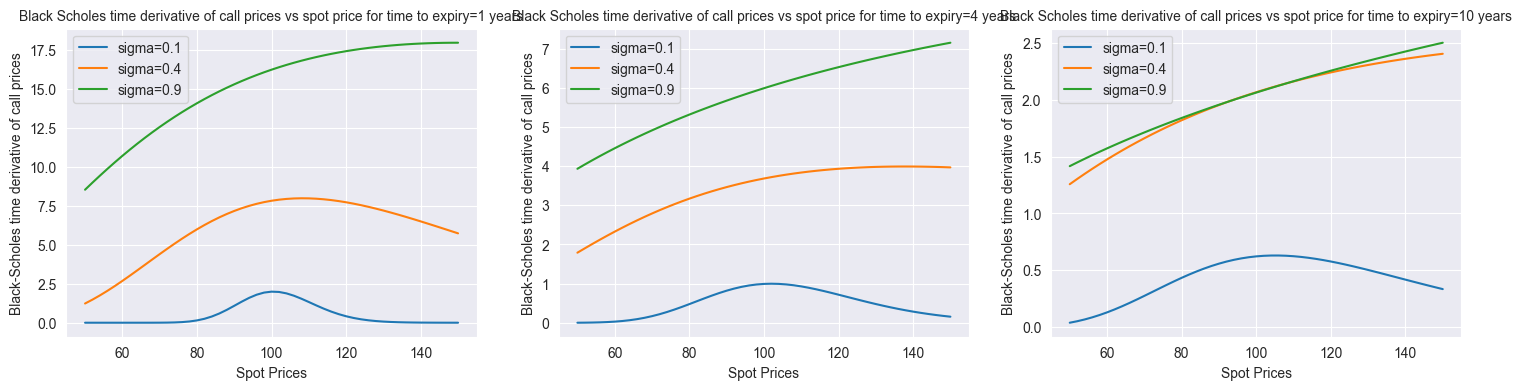

In [ ]:
spot_prices = [i for i in range(50,151, 2)]
K = 100
sigma_list = [0.1, 0.4, 0.9]
times = [1,4,10]
epsilon=0.005

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for j in range(len(times)):
    for sigma in sigma_list:
        axes[j].plot(spot_prices, [(bs_call(S,100,sigma, t = times[j]*(1+epsilon)) - bs_call(S,100,sigma, t = times[j]*(1-epsilon)))/(2*times[j]*epsilon) for S in spot_prices], label=f'sigma={sigma}')
    axes[j].set_xlabel('Spot Prices')
    axes[j].set_ylabel('Black-Scholes time derivative of call prices')
    axes[j].set_title(f'Black Scholes time derivative of call prices vs spot price for time to expiry={times[j]} years', size = 10)
    axes[j].legend()

plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for j in range(len(times)):
    for sigma in sigma_list:
        axes[j].plot(spot_prices, [(bs_put(S,100,sigma, t = times[j]*(1+epsilon)) - bs_put(S,100,sigma, t = times[j]*(1-epsilon)))/(2*times[j]*epsilon) for S in spot_prices], label=f'sigma={sigma}')
    axes[j].set_xlabel('Spot Prices')
    axes[j].set_ylabel('Black-Scholes time derivative of put prices')
    axes[j].set_title(f'Black Scholes time derivative of put prices vs spot price for time to expiry={times[j]} years', size = 10)
    axes[j].legend()

plt.show()

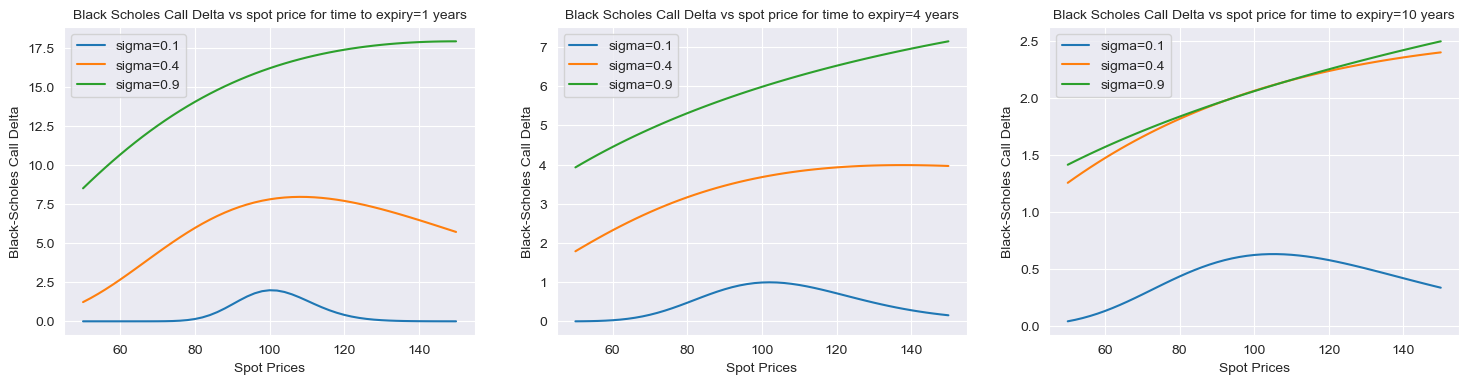

In [ ]:
spot_prices = [i for i in range(50,151, 2)]
K = 100
sigma_list = [0.1, 0.4, 0.9]
times = [1,4,10]
epsilon=0.005

